In [ ]:
import kagglehub

path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [ ]:
# ==========================================
# STEP 2: Download Dataset (Using Kagglehub)
# ==========================================
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [ ]:
import os

In [ ]:
# Determine the actual data directory.
# If the images are nested in a 'PetImages' folder, we point to that.
if 'PetImages' in os.listdir(path):
    base_dir = os.path.join(path, 'PetImages')
else:
    base_dir = path

In [ ]:
import os
import kagglehub
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [ ]:
# ==========================================
# STEP 3: Image Preprocessing (Auto-Splitting)
# ==========================================
# Use validation_split=0.2 to reserve 20% of the data for validation.
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [ ]:
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'      # Automatically grabs the 80% split
)

Found 20000 images belonging to 2 classes.


In [ ]:
validation_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'    # Automatically grabs the 20% split
)

Found 4998 images belonging to 2 classes.


In [ ]:
# ==========================================
# STEP 4: Build CNN Model
# ==========================================
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # binary output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ==========================================
# STEP 5: Compile Model
# ==========================================
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
# ==========================================
# STEP 6: Train the Model
# ==========================================
# steps_per_epoch is removed so Keras auto-calculates based on the full dataset size
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
 61/625 ━━━━━━━━━━━━━━━━━━━━ 1:55 206ms/step - accuracy: 0.5100 - loss: 1.0337

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 246ms/step - accuracy: 0.6743 - loss: 0.5961 - val_accuracy: 0.7457 - val_loss: 0.5065
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.7796 - loss: 0.4647 - val_accuracy: 0.7663 - val_loss: 0.5098
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8245 - loss: 0.3869 - val_accuracy: 0.8181 - val_loss: 0.4012
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8720 - loss: 0.3000 - val_accuracy: 0.8255 - val_loss: 0.3894
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9175 - loss: 0.2024 - val_accuracy: 0.8337 - val_loss: 0.4307
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9564 - loss: 0.1159 - val_accuracy: 0.8237 - val_loss: 0.5337
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 106ms/step - accuracy: 0.9814 - loss: 0.0551 - val_accuracy: 0.8251 - val_loss: 0.7001
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.9885 - loss: 0.0370 - val_accu

In [3]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("cat_dog_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model created successfully!")

Saved artifact at '/tmp/tmphm9m62d2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137994990337680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994990337872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994990336144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994987750608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994987750416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994987749648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994990336720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994987749456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994987750032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994987750224: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model cre

In [4]:
from google.colab import files

files.download("cat_dog_model.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

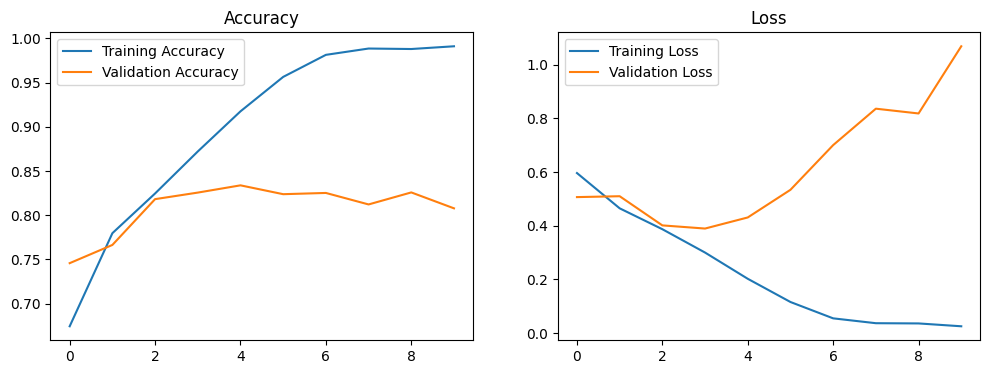

In [ ]:
# ==========================================
# STEP 7: Plot Accuracy and Loss
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()